In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set the root directory path explicitly
root_dir = r"c:\Users\jimvo\Documents\Recurrent-PPO-Jax"
sys.path.append(root_dir)

# Now import the class
from tasks.envs.jax_env.jax_function_samplers import initialize_sampler

from src.tasks.envs.base_fun_env import BaseOptimizationEnv
from src.tasks.envs.function_envs.ackley_env import AckleyEnv
from src.tasks.envs.function_envs.poly_env import PolyEnv
from src.tasks.envs.function_envs.cosine_env import CosineEnv


In [2]:
def plot_env(env, title, resolution=100):
    """
    Plot the function defined by the environment.
    - For 1D input (action_dim==1): produces a 2D plot (x vs. f(x)).
    - For 2D input (action_dim==2): produces a 3D surface plot (x1, x2, f(x)).
    """
    if env.action_dim == 1:
        # 1D input: create a line plot.
        x_vals = np.linspace(env.x_range[0], env.x_range[1], resolution)
        # Reshape to (N, 1) if needed.
        y_vals = env.compute_y(x_vals.reshape(-1, 1))
        plt.figure(figsize=(8, 4))
        plt.plot(x_vals, y_vals, label='f(x)')
        # Plot the optimum point.
        opt_val = env.compute_y(np.array(env.optimum_point).reshape(1, -1))
        plt.scatter(env.optimum_point, opt_val, color='red', marker='x', s=100, label='Optimum')
        plt.title(f"{title} (1D)")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.show()
    elif env.action_dim == 2:
        # 2D input: create a 3D surface plot.
        x_vals = np.linspace(env.x_range[0], env.x_range[1], resolution)
        y_vals = np.linspace(env.x_range[0], env.x_range[1], resolution)
        X, Y = np.meshgrid(x_vals, y_vals)
        grid_points = np.column_stack([X.ravel(), Y.ravel()])
        Z = env.compute_y(grid_points)
        Z = Z.reshape(X.shape)
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
        fig.colorbar(surf, shrink=0.5, aspect=10, label='f(x)')
        # Plot the optimum point.
        opt_val = env.compute_y(np.array(env.optimum_point).reshape(1, -1))
        opt_inp = np.squeeze(env.optimum_point)
        ax.scatter(opt_inp[0], opt_inp[1], opt_val,
                   color='red', marker='x', s=100, label='Optimum')
        ax.set_title(f"{title} (2D)")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_zlabel("f(x)")
        ax.legend()
        plt.show()


def plot_multiple_runs(env_class, config, title, num_runs=10, resolution=100):
    """
    Run multiple initializations of an environment and plot:
      - (Left subplot) the function curves (or contours for 2D) over the given domain,
        overlaid for each run.
      - (Right subplot) the distribution of the optimum (max) values.
          For a 1D input this is a histogram of optimum x values.
          For a 2D input this is a scatter plot of optimum (x1,x2) points.
    The distribution plot bounds are set to the actual bounds provided in the configuration.
    
    Parameters:
      env_class: The environment class (e.g., AckleyEnv, CosineEnv, PolyEnv)
      config: Configuration dictionary for the environment.
      title: Title string for labeling the plots.
      num_runs: Number of random initializations to perform.
      resolution: Number of points for plotting the function curve.
    """
    # Create the figure with 2 subplots in one row.
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    
    # List to store optimum points
    optimum_vals = []
    
    for i in range(num_runs):
        env = env_class(config)
        env.initialize_function()
        
        if env.action_dim == 1:
            # Create a 1D grid over the entire domain.
            x_vals = np.linspace(config["bounds"][0], config["bounds"][1], resolution)
            y_vals = env.compute_y(x_vals.reshape(-1, 1))
            # Plot the function. Use a semi-transparent line for overlay.
            axs[0].plot(x_vals, y_vals, alpha=0.6)
            # Record the optimum x value.
            optimum_vals.append(np.squeeze(env.optimum_point[0]))
            
        elif env.action_dim == 2:
            # Create a 2D grid over the domain.
            x_vals = np.linspace(config["bounds"][0], config["bounds"][1], resolution)
            y_vals = np.linspace(config["bounds"][0], config["bounds"][1], resolution)
            X, Y = np.meshgrid(x_vals, y_vals)
            grid_points = np.column_stack([X.ravel(), Y.ravel()])
            Z = env.compute_y(grid_points)
            Z = Z.reshape(X.shape)
            # Draw a contour plot (using a few contour levels with transparency).
            axs[0].contour(X, Y, Z, levels=10, alpha=0.6)
            # Record the optimum point (as a 2-element array).
            optimum_vals.append(np.squeeze(env.optimum_point))
        else:
            raise ValueError("Unsupported action_dim, only 1 or 2 allowed.")
    
    # Format the left subplot.
    if config["action_dim"] == 1:
        axs[0].set_title(f"{title} Over Multiple Runs (1D)")
        axs[0].set_xlabel("x")
        axs[0].set_ylabel("f(x)")
    elif config["action_dim"] == 2:
        axs[0].set_title(f"{title} Over Multiple Runs (2D Contour)")
        axs[0].set_xlabel("x1")
        axs[0].set_ylabel("x2")
    
    # Create the right subplot to show the distribution.
    if config["action_dim"] == 1:
        # Draw a histogram of optimum x values.
        bins = np.linspace(config["bounds"][0], config["bounds"][1], 40)
        print("optimum_vals", np.array(optimum_vals).shape)
        axs[1].hist(optimum_vals, bins=bins, color='gray', edgecolor='black')
        axs[1].set_title("Distribution of Optimum x Values")
        axs[1].set_xlabel("x")
        axs[1].set_ylabel("Frequency")
        axs[1].set_xlim(config["bounds"][0], config["bounds"][1])
    elif config["action_dim"] == 2:
        # Convert list to array for 2D points.
        optimum_vals = np.array(optimum_vals)
        axs[1].scatter(optimum_vals[:, 0], optimum_vals[:, 1], color='red', marker='x')
        axs[1].set_title("Distribution of Optimum Points")
        axs[1].set_xlabel("x1")
        axs[1].set_ylabel("x2")
        axs[1].set_xlim(config["bounds"][0], config["bounds"][1])
        axs[1].set_ylim(config["bounds"][0], config["bounds"][1])
    
    plt.tight_layout()
    plt.show()


In [3]:
standard_config_1d = {
    "bounds": (-5.0, 5.0),
    "action_dim": 1,
    "max_episode_steps": 1,
    "total_episode_samples": 1,
    "batches": [1,1],
    "max_batches": 1,
    "random": False, 
    "task": "name",
}

standard_config_2d = {
    "bounds": (-5.0, 5.0),
    "action_dim": 2,
    "max_episode_steps": 1,
    "total_episode_samples": 1,
    "batches": [1,1],
    "max_batches": 1,
    "random": False, 
    "task": "name",
}

optimum_vals (50,)


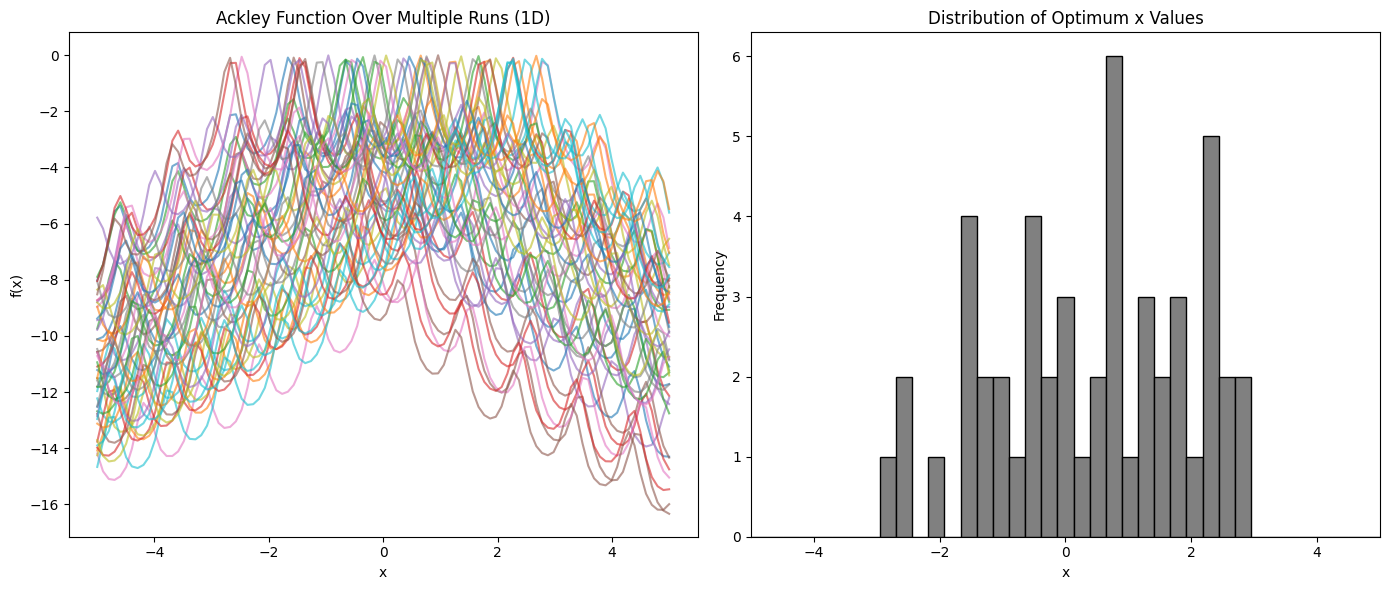

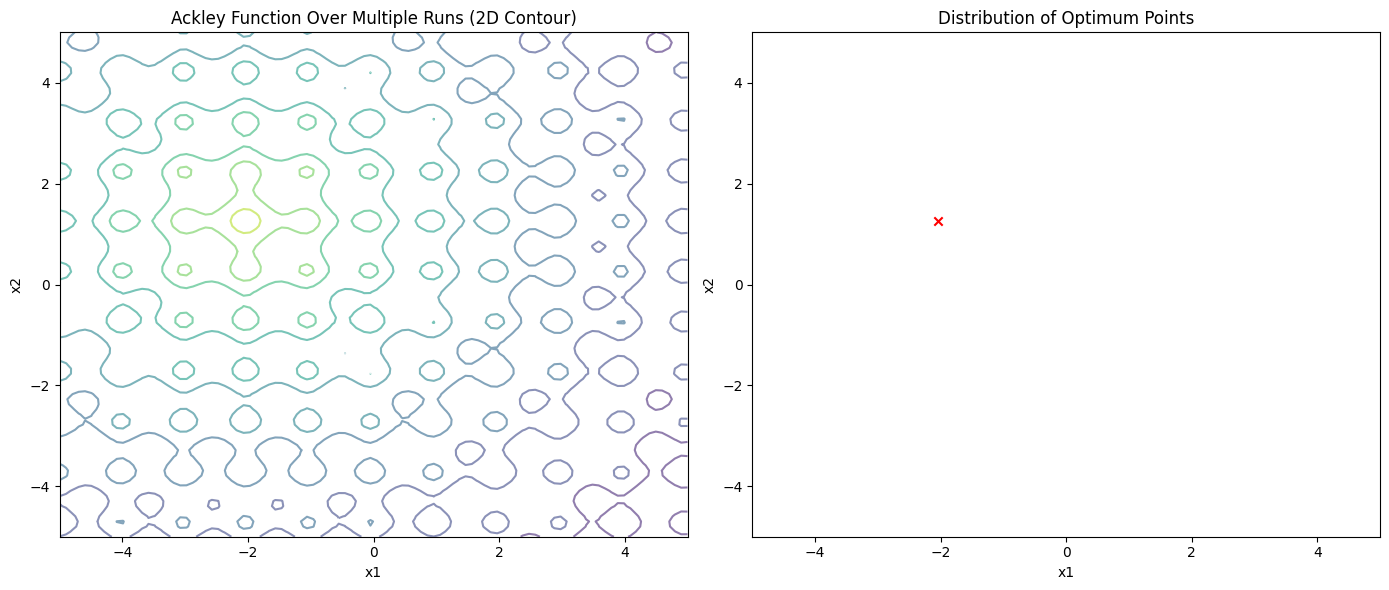

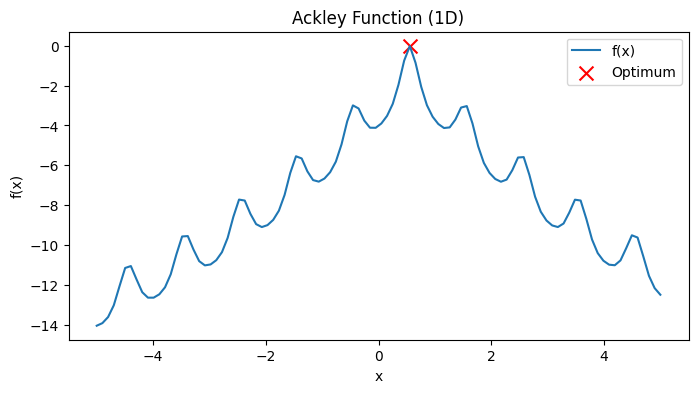

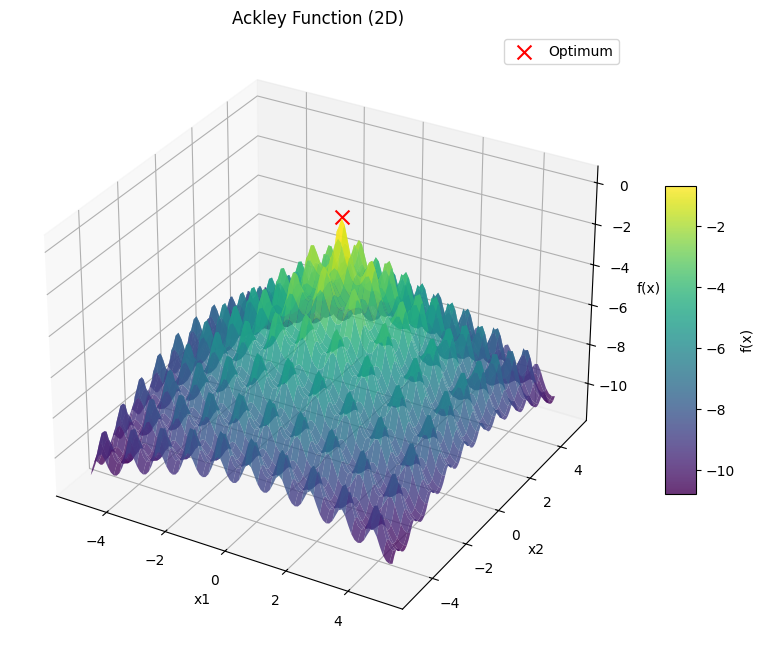

In [4]:
ackley_addtional_config = {
    "a_bounds": (15.0, 20.0),
    "b_bounds": (0.1, 0.2),
    "c_bounds": (2 * np.pi, 2 * np.pi),
}
ackley_config_1d = standard_config_1d | ackley_addtional_config
ackley_config_2d = standard_config_2d | ackley_addtional_config

ackley_env_1d = AckleyEnv(ackley_config_1d)
ackley_env_1d.initialize_function()
ackley_env_2d = AckleyEnv(ackley_config_2d)
ackley_env_2d.initialize_function()

plot_multiple_runs(AckleyEnv, ackley_config_1d, "Ackley Function", num_runs=50, resolution=100)
plot_multiple_runs(AckleyEnv, ackley_config_2d, "Ackley Function", num_runs=1, resolution=100)
plot_env(ackley_env_1d, "Ackley Function")
plot_env(ackley_env_2d, "Ackley Function")


optimum_vals (50,)


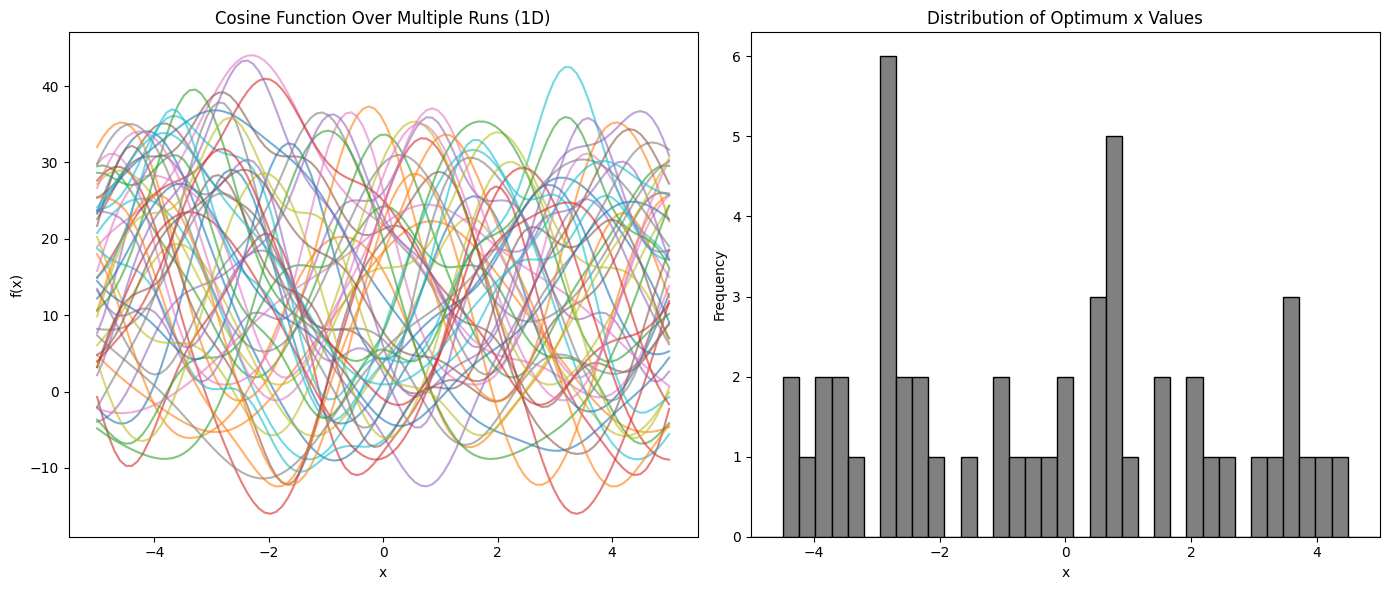

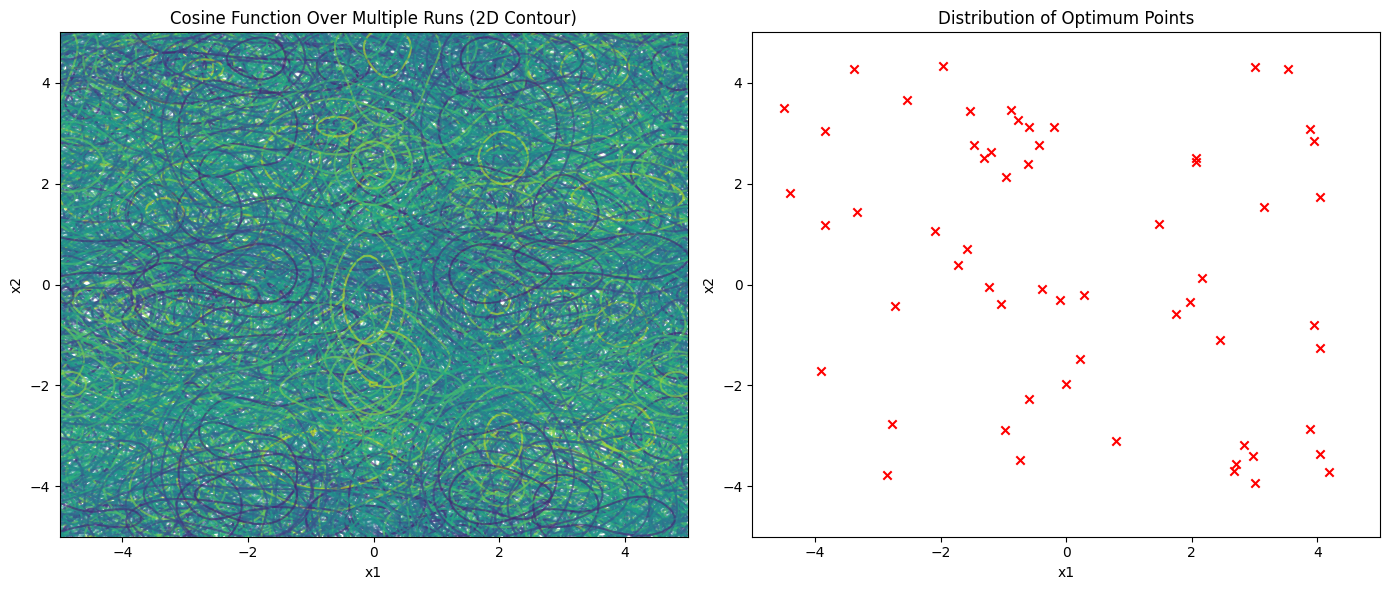

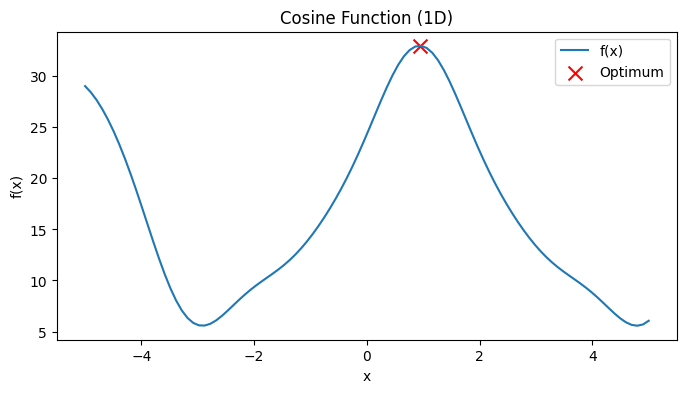

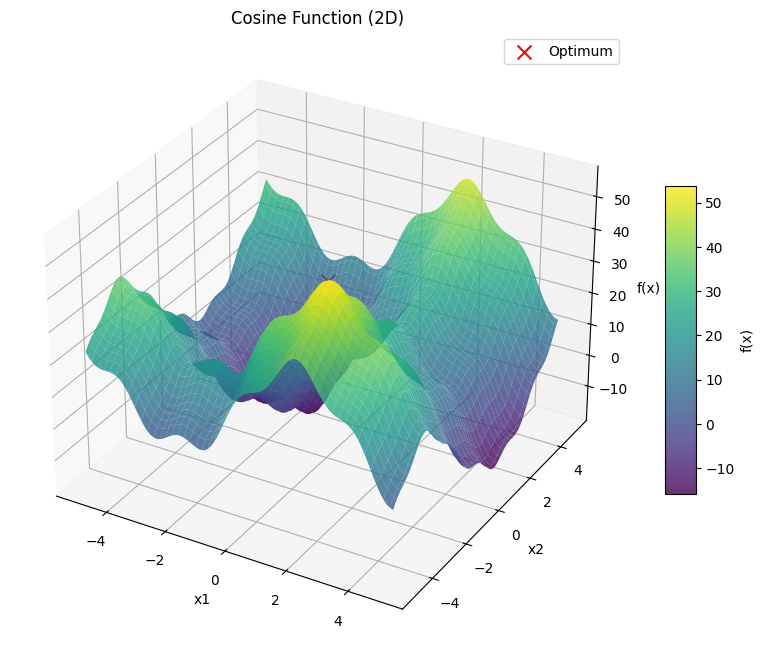

In [5]:
cosine_addtional_config = {
    "num_oscillations": 3,
    "c_bounds": (5.0, 20.0),
    "A_bounds": (10.0, 20.0),
    "B_bounds": (0.5, 1.5),
    "small_A_bounds": (0.2, 3.0),
    "small_B_bounds": (0.5, 4.0),
}

cosine_config_1d = standard_config_1d | cosine_addtional_config
cosine_config_2d = standard_config_2d | cosine_addtional_config

cosine_env_1d = CosineEnv(cosine_config_1d)
cosine_env_1d.initialize_function()
cosine_env_2d = CosineEnv(cosine_config_2d)
cosine_env_2d.initialize_function()

plot_multiple_runs(CosineEnv, cosine_config_1d, "Cosine Function", num_runs=50, resolution=100)
plot_multiple_runs(CosineEnv, cosine_config_2d, "Cosine Function", num_runs=60, resolution=100)
plot_env(cosine_env_1d, "Cosine Function")
plot_env(cosine_env_2d, "Cosine Function")

optimum_vals (50,)


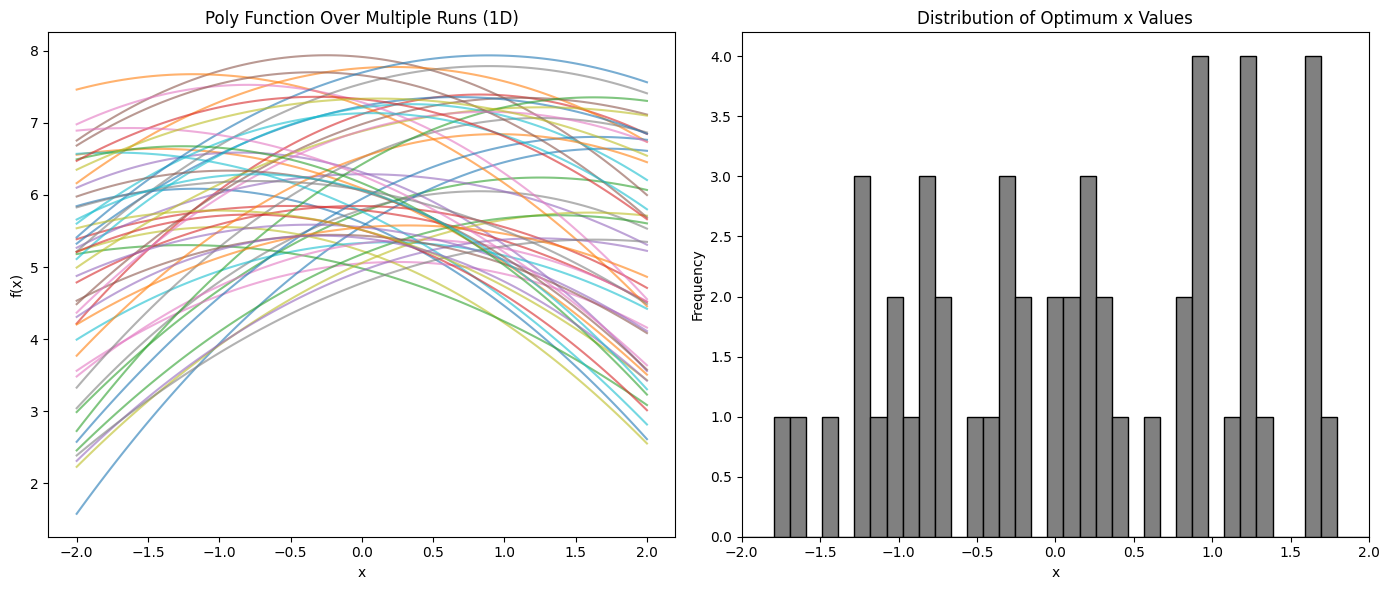

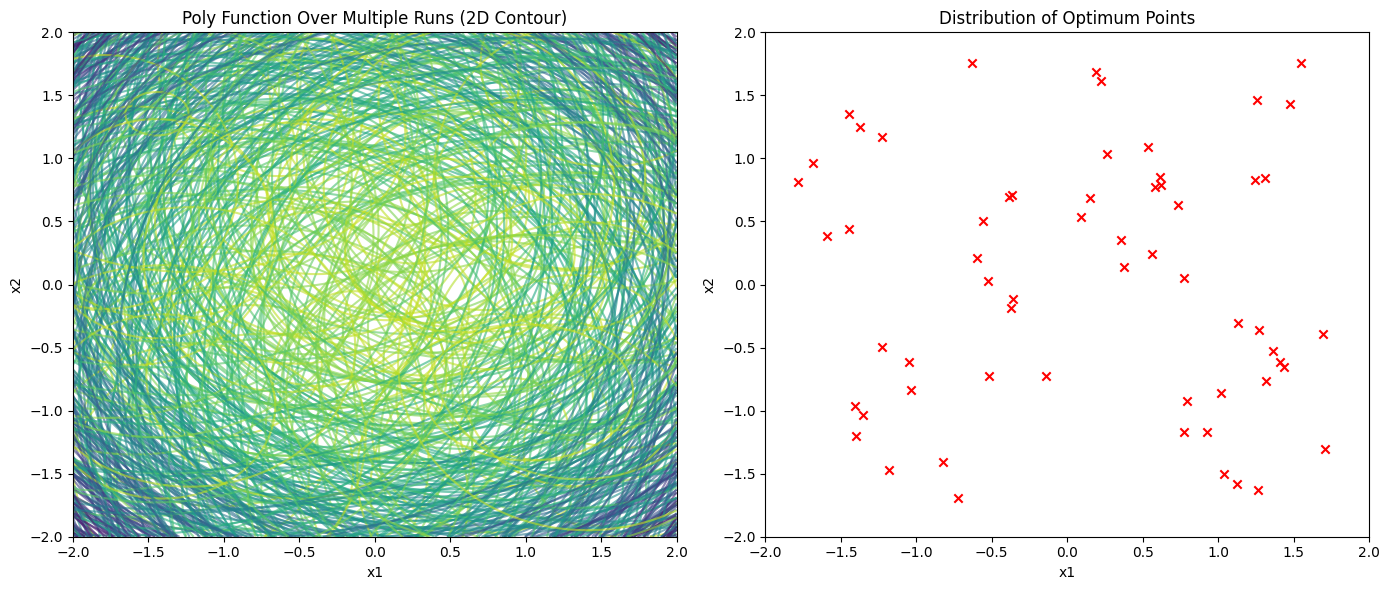

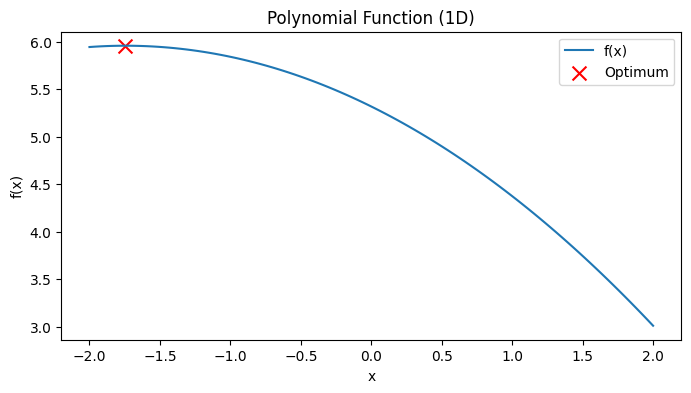

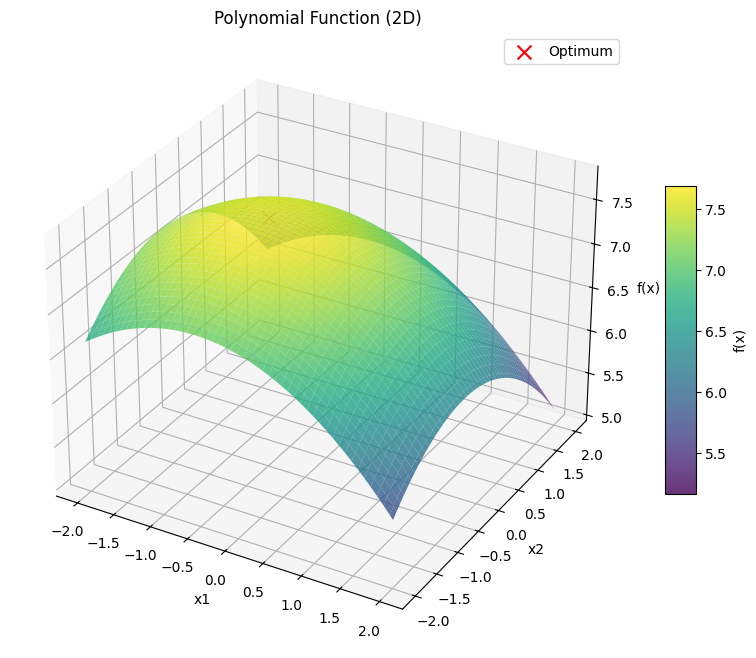

In [7]:
poly_addtional_config = {
    "degree": 2,
    "bounds": (-2.0, 2.0),
    "c_bounds": (5.0, 8.0),
    "x_bounds": (0.2, 0.4),
}

poly_config_1d = standard_config_1d | poly_addtional_config
poly_config_2d = standard_config_2d | poly_addtional_config

poly_env_1d = PolyEnv(poly_config_1d)
poly_env_1d.initialize_function()
poly_env_2d = PolyEnv(poly_config_2d)
poly_env_2d.initialize_function()

plot_multiple_runs(PolyEnv, poly_config_1d, "Poly Function", num_runs=50, resolution=100)
plot_multiple_runs(PolyEnv, poly_config_2d, "Poly Function", num_runs=60, resolution=100)
plot_env(poly_env_1d, "Polynomial Function")
plot_env(poly_env_2d, "Polynomial Function")